# The Error-State Kalman Filter (ESKF)

This notebook builds an Error-State Kalman Filter for 3D motion from first principles and runs it on an IMU + 6D pose dataset. It is written in the spirit of Roger Labbe's [*Kalman and Bayesian Filters in Python*](https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python) (chapter 11 covers the EKF), and it follows the notation and equation numbers of

> J. Solà, *Quaternion kinematics for the error-state Kalman filter*, 2017. [arXiv:1711.02508](https://arxiv.org/abs/1711.02508)

**What you will see**

1. Why we filter the *error* instead of the state
2. A small quaternion toolbox (⊗, Exp, Log, ⊞, ⊟)
3. True, nominal and error state
4. Prediction: nominal kinematics and the error-state Jacobian (with a numerical check)
5. Correction: update, injection and reset
6. A dataset: 200 Hz IMU, 10 Hz 6D pose, with a 10 s measurement dropout
7. Running the filter, and comparing against pure IMU dead reckoning
8. Is the filter honest? Monte Carlo NEES and NIS consistency tests
9. Exercises

The code is split into short functions. Each one appears right after the equation it implements and is followed by a small test, so you can check every piece before it is used. Run the cells from top to bottom.

In [1]:
%matplotlib inline
import os
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(precision=4, suppress=True)

## 1. Why an *error-state* filter?

In the EKF chapter the state is estimated directly: $\mathbf x \sim \mathcal N(\hat{\mathbf x}, \mathbf P)$. That works nicely for positions and velocities. It becomes awkward for **orientation**:

* A unit quaternion has 4 numbers but only 3 degrees of freedom. A $4\times4$ covariance on it is singular in the direction that violates $\|\mathbf q\|=1$, and after every update the quaternion leaves the unit sphere and must be renormalised, which the covariance knows nothing about.
* Euler angles have 3 numbers but suffer from singularities (gimbal lock) and strong non-linearity.

The ESKF splits the problem in two:

| | **Nominal state** $\mathbf x$ | **Error state** $\delta\mathbf x$ |
|---|---|---|
| holds | the large signal (e.g. a quaternion) | the small deviation from it |
| integrated | non-linearly, no noise | linearly, carries all the noise |
| orientation | $\mathbf q \in S^3$ (4 numbers) | $\delta\boldsymbol\theta \in \mathbb R^3$ (3 numbers, minimal) |
| mean | – | always reset to **0** after a correction |

Solà (Sec. 5) lists the benefits:

* the orientation error is a minimal 3-vector, so $\mathbf P$ is never singular;
* the error stays close to zero, where the linearisation is excellent and $\sin\theta\approx\theta$ holds;
* the error dynamics are slow (the large signal is in the nominal state), so the Kalman corrections can run at a lower rate than the IMU.

The price is two extra steps after each correction: **inject** the error into the nominal state, then **reset** the error to zero.

## 2. A small quaternion toolbox

We need only a handful of operations on rotations. We build them one at a time and test each one.

Conventions used throughout:

* Hamilton quaternions, stored as $\mathbf q = [q_w, q_x, q_y, q_z]$.
* $\mathbf q$ rotates body-frame vectors into the world frame: $\mathbf x_{world} = \mathbf R(\mathbf q)\,\mathbf x_{body}$.

### 2.1 The skew-symmetric matrix

$[\mathbf a]_\times$ turns a cross product into a matrix product: $[\mathbf a]_\times\mathbf b = \mathbf a\times\mathbf b$. It appears in almost every Jacobian below.

In [2]:
def skew(a):
    """[a]x such that skew(a) @ b == np.cross(a, b)."""
    x, y, z = a
    return np.array([[0.0, -z,   y],
                     [z,   0.0, -x],
                     [-y,  x,   0.0]])

In [3]:
a, b = np.array([1.0, 2.0, 3.0]), np.array([-0.5, 0.4, 2.0])
print("skew(a) @ b  :", skew(a) @ b)
print("np.cross(a,b):", np.cross(a, b))

skew(a) @ b  : [ 2.8 -3.5  1.4]
np.cross(a,b): [ 2.8 -3.5  1.4]


### 2.2 Quaternion product and conjugate

Composing two rotations is the quaternion product $\mathbf p\otimes\mathbf q$ (Solà eq. 12). The conjugate $\mathbf q^* = [q_w, -q_x, -q_y, -q_z]$ is the inverse rotation.

In [4]:
def q_mult(p, q):
    """Quaternion product p ⊗ q."""
    pw, px, py, pz = p
    qw, qx, qy, qz = q
    return np.array([pw*qw - px*qx - py*qy - pz*qz,
                     pw*qx + px*qw + py*qz - pz*qy,
                     pw*qy - px*qz + py*qw + pz*qx,
                     pw*qz + px*qy - py*qx + pz*qw])


def q_conj(q):
    """Conjugate q*, the inverse of a unit quaternion."""
    return np.array([q[0], -q[1], -q[2], -q[3]])

In [5]:
q = np.array([0.8, 0.2, -0.4, 0.4]); q = q / np.linalg.norm(q)
p = np.array([0.6, 0.0, 0.8, 0.0])
print("q ⊗ q*       :", q_mult(q, q_conj(q)), " (identity)")
print("p ⊗ q        :", q_mult(p, q))
print("q ⊗ p        :", q_mult(q, p), " (different: rotations do not commute)")

q ⊗ q*       : [1. 0. 0. 0.]  (identity)
p ⊗ q        : [0.8  0.44 0.4  0.08]
q ⊗ p        : [ 0.8 -0.2  0.4  0.4]  (different: rotations do not commute)


### 2.3 Exp and Log: rotation vectors ↔ quaternions

A rotation by angle $\theta$ about unit axis $\mathbf u$ can be written as the 3-vector $\boldsymbol\theta = \theta\mathbf u$. The exponential and logarithmic maps convert between the two forms (Solà eqs. 101, 105):

$$
\mathrm{Exp}(\theta\mathbf u) = \begin{bmatrix}\cos(\theta/2)\\ \mathbf u\sin(\theta/2)\end{bmatrix},
\qquad
\mathrm{Log}(\mathbf q) = \theta\mathbf u .
$$

These two maps are the key to the ESKF. The *error* in orientation will be a small 3-vector $\delta\boldsymbol\theta$, and Exp turns it into a quaternion we can apply.

In [6]:
def q_normalize(q):
    return q / np.linalg.norm(q)


def q_exp(rotvec):
    """Rotation vector θu  ->  unit quaternion."""
    rotvec = np.asarray(rotvec, dtype=float)
    theta = np.linalg.norm(rotvec)
    if theta < 1e-10:                                   # tiny angle: first-order approximation
        return q_normalize(np.array([1.0, *(0.5 * rotvec)]))
    u = rotvec / theta
    return np.array([np.cos(theta / 2), *(np.sin(theta / 2) * u)])


def q_log(q):
    """Unit quaternion  ->  rotation vector θu."""
    q = np.asarray(q, dtype=float)
    if q[0] < 0:                                        # q and -q are the same rotation
        q = -q
    v = q[1:]
    norm_v = np.linalg.norm(v)
    if norm_v < 1e-10:
        return 2.0 * v
    return 2.0 * np.arctan2(norm_v, q[0]) * v / norm_v

In [7]:
theta = np.array([0.0, 0.0, np.pi / 2])                 # 90° about z
print("Exp(90° about z):", q_exp(theta))
print("Log(Exp(θ)) == θ:", np.allclose(q_log(q_exp(theta)), theta))
print("Log(-q) == Log(q):", np.allclose(q_log(-q_exp(theta)), theta))

Exp(90° about z): [0.7071 0.     0.     0.7071]
Log(Exp(θ)) == θ: True
Log(-q) == Log(q): True


### 2.4 Rotation matrix

For rotating vectors it is convenient to convert $\mathbf q$ to a $3\times3$ rotation matrix $\mathbf R(\mathbf q)$ (Solà eq. 115).

In [8]:
def q_to_R(q):
    """Rotation matrix with x_world = R @ x_body."""
    w, x, y, z = q
    return np.array([[1 - 2*(y*y + z*z), 2*(x*y - w*z),     2*(x*z + w*y)],
                     [2*(x*y + w*z),     1 - 2*(x*x + z*z), 2*(y*z - w*x)],
                     [2*(x*z - w*y),     2*(y*z + w*x),     1 - 2*(x*x + y*y)]])

In [9]:
R = q_to_R(q_exp([0.0, 0.0, np.pi / 2]))
print("x-axis rotated 90° about z:", R @ np.array([1.0, 0.0, 0.0]), " (should be the y-axis)")
print("R Rᵀ == I:", np.allclose(R @ R.T, np.eye(3)))

x-axis rotated 90° about z: [0. 1. 0.]  (should be the y-axis)
R Rᵀ == I: True


### 2.5 "Plus" and "minus" for rotations

Vectors can be added and subtracted. Rotations cannot, but we can define the equivalent operations with Exp and Log. We use a **local** perturbation, meaning the small rotation is applied in the body frame (on the right):

$$
\mathbf q \boxplus \delta\boldsymbol\theta = \mathbf q \otimes \mathrm{Exp}(\delta\boldsymbol\theta),
\qquad
\mathbf q_1 \boxminus \mathbf q_0 = \mathrm{Log}(\mathbf q_0^{*} \otimes \mathbf q_1).
$$

$\boxplus$ applies a small rotation. $\boxminus$ answers "which small rotation takes $\mathbf q_0$ to $\mathbf q_1$?".

In [10]:
def q_boxplus(q, dtheta):
    """q ⊞ δθ : apply a small body-frame rotation δθ to q."""
    return q_normalize(q_mult(q, q_exp(dtheta)))


def q_boxminus(q1, q0):
    """q1 ⊟ q0 : the small body-frame rotation that takes q0 to q1."""
    return q_log(q_mult(q_conj(q0), q1))

In [11]:
q0 = q_exp([0.3, -0.2, 0.5])
dtheta = np.array([0.01, -0.02, 0.03])
q1 = q_boxplus(q0, dtheta)
print("(q0 ⊞ δθ) ⊟ q0 :", q_boxminus(q1, q0), " (should equal δθ)")

(q0 ⊞ δθ) ⊟ q0 : [ 0.01 -0.02  0.03]  (should equal δθ)


## 3. True, nominal and error state

For an IMU-driven body we use (Solà Sec. 5.3, with gravity assumed known):

$$
\underbrace{\mathbf x = \begin{bmatrix}\mathbf p\\ \mathbf v\\ \mathbf q\\ \mathbf a_b\\ \boldsymbol\omega_b\end{bmatrix}}_{\text{nominal, 16}}
\qquad
\underbrace{\delta\mathbf x = \begin{bmatrix}\delta\mathbf p\\ \delta\mathbf v\\ \delta\boldsymbol\theta\\ \delta\mathbf a_b\\ \delta\boldsymbol\omega_b\end{bmatrix}}_{\text{error, 15}}
\qquad
\mathbf x_t = \mathbf x \oplus \delta\mathbf x =
\begin{bmatrix}\mathbf p + \delta\mathbf p\\ \mathbf v + \delta\mathbf v\\ \mathbf q\otimes\mathrm{Exp}(\delta\boldsymbol\theta)\\ \mathbf a_b + \delta\mathbf a_b\\ \boldsymbol\omega_b + \delta\boldsymbol\omega_b\end{bmatrix}
$$

$\mathbf p, \mathbf v$ are position and velocity in the world frame, $\mathbf q$ is body-to-world orientation, and $\mathbf a_b, \boldsymbol\omega_b$ are the accelerometer and gyroscope biases.

The IMU measures specific force and angular rate in the body frame, corrupted by bias and white noise:

$$
\mathbf a_m = \mathbf R_t^\top(\mathbf a_t - \mathbf g) + \mathbf a_{bt} + \mathbf a_n,
\qquad
\boldsymbol\omega_m = \boldsymbol\omega_t + \boldsymbol\omega_{bt} + \boldsymbol\omega_n,
$$

and the biases follow random walks $\dot{\mathbf a}_{bt} = \mathbf a_w$, $\dot{\boldsymbol\omega}_{bt} = \boldsymbol\omega_w$.

In code, a state is a small dictionary with the keys `p, v, q, ab, wb`. The $\oplus$ and $\ominus$ operations follow the definition above one line at a time. Named slices tell us where each block lives inside the 15-dim error vector.

In [12]:
P_IDX, V_IDX, TH_IDX, AB_IDX, WB_IDX = slice(0, 3), slice(3, 6), slice(6, 9), slice(9, 12), slice(12, 15)


def state_plus(x, dx):
    """x ⊕ δx : apply a 15-dim error to a nominal state."""
    return dict(p=x["p"] + dx[P_IDX],
                v=x["v"] + dx[V_IDX],
                q=q_boxplus(x["q"], dx[TH_IDX]),
                ab=x["ab"] + dx[AB_IDX],
                wb=x["wb"] + dx[WB_IDX])


def state_minus(x_true, x):
    """x_true ⊖ x : the 15-dim error that takes x to x_true."""
    return np.r_[x_true["p"] - x["p"],
                 x_true["v"] - x["v"],
                 q_boxminus(x_true["q"], x["q"]),
                 x_true["ab"] - x["ab"],
                 x_true["wb"] - x["wb"]]

In [13]:
x_nominal = dict(p=np.zeros(3), v=np.array([1.0, 0.0, 0.0]), q=q_exp([0.1, 0.2, 0.3]),
                 ab=np.zeros(3), wb=np.zeros(3))
dx = np.random.default_rng(0).normal(scale=0.01, size=15)
x_true = state_plus(x_nominal, dx)
print("(x ⊕ δx) ⊖ x == δx :", np.allclose(state_minus(x_true, x_nominal), dx))

(x ⊕ δx) ⊖ x == δx : True


## 4. Prediction

### 4.1 Nominal state (non-linear, no noise)

Discretised with step $\Delta t$ (Solà eq. 260):

$$
\begin{aligned}
\mathbf p &\leftarrow \mathbf p + \mathbf v\Delta t + \tfrac12\big(\mathbf R(\mathbf a_m - \mathbf a_b) + \mathbf g\big)\Delta t^2\\
\mathbf v &\leftarrow \mathbf v + \big(\mathbf R(\mathbf a_m - \mathbf a_b) + \mathbf g\big)\Delta t\\
\mathbf q &\leftarrow \mathbf q \otimes \mathrm{Exp}\big((\boldsymbol\omega_m - \boldsymbol\omega_b)\Delta t\big)\\
\mathbf a_b &\leftarrow \mathbf a_b, \qquad \boldsymbol\omega_b \leftarrow \boldsymbol\omega_b
\end{aligned}
$$


The IMU noise parameters are collected in a small container first.

In [14]:
@dataclass
class ESKFParams:
    """IMU noise, discrete and per sample (Solà eq. 262)."""
    sigma_an: float = 0.05     # accelerometer white noise        [m/s²]
    sigma_wn: float = 0.005    # gyroscope white noise            [rad/s]
    sigma_aw: float = 0.002    # accelerometer bias random walk   [m/s² / √s]
    sigma_ww: float = 0.0002   # gyroscope bias random walk       [rad/s / √s]
    gravity: tuple = (0.0, 0.0, -9.81)

In [15]:
def nominal_predict(x, a_m, w_m, dt, params):
    """Propagate the nominal state with one IMU sample (no noise)."""
    g = np.array(params.gravity)
    acc_world = q_to_R(x["q"]) @ (a_m - x["ab"]) + g     # remove bias, rotate to world, add gravity
    w_body = w_m - x["wb"]                                # remove gyro bias
    return dict(p=x["p"] + x["v"] * dt + 0.5 * acc_world * dt**2,
                v=x["v"] + acc_world * dt,
                q=q_boxplus(x["q"], w_body * dt),
                ab=x["ab"].copy(),                        # biases are constant here
                wb=x["wb"].copy())

**Test.** An IMU lying still on a table measures the reaction to gravity, $\mathbf a_m = [0, 0, +9.81]$, and no rotation. Integrating that should leave the body at rest. Then we add a small accelerometer bias the filter does not know about, and watch what integration makes of it.

In [16]:
params = ESKFParams()
x_rest = dict(p=np.zeros(3), v=np.zeros(3), q=np.array([1.0, 0, 0, 0]), ab=np.zeros(3), wb=np.zeros(3))
dt = 0.005

x = x_rest
for _ in range(2000):                                      # 10 s at 200 Hz
    x = nominal_predict(x, np.array([0, 0, 9.81]), np.zeros(3), dt, params)
print("perfect IMU, after 10 s: p =", x["p"])

x = x_rest
for _ in range(2000):
    x = nominal_predict(x, np.array([0.05, 0, 9.81]), np.zeros(3), dt, params)   # 0.05 m/s² bias
print("biased IMU,  after 10 s: p =", x["p"], " (½·0.05·10² = 2.5 m)")

perfect IMU, after 10 s: p = [0. 0. 0.]
biased IMU,  after 10 s: p = [2.5 0.  0. ]  (½·0.05·10² = 2.5 m)


A bias of only $0.05$ m/s² already produces $2.5$ m of position error in $10$ s. The filter will have to *estimate* the biases, which is why they are part of the state.

### 4.2 Error state (linear, carries the noise)

The error mean is zero and stays zero during prediction, so only its covariance moves:

$$
\mathbf P \leftarrow \mathbf F_x\,\mathbf P\,\mathbf F_x^\top + \mathbf F_i\,\mathbf Q_i\,\mathbf F_i^\top
$$

with the error-state transition matrix (Solà eq. 269)

$$
\mathbf F_x = \begin{bmatrix}
\mathbf I & \mathbf I\Delta t & 0 & 0 & 0\\
0 & \mathbf I & -\mathbf R[\mathbf a_m-\mathbf a_b]_\times\Delta t & -\mathbf R\Delta t & 0\\
0 & 0 & \mathbf R^\top\{(\boldsymbol\omega_m-\boldsymbol\omega_b)\Delta t\} & 0 & -\mathbf I\Delta t\\
0 & 0 & 0 & \mathbf I & 0\\
0 & 0 & 0 & 0 & \mathbf I
\end{bmatrix}
$$

and the noise mapping $\mathbf F_i$ (noise enters $\delta\mathbf v, \delta\boldsymbol\theta, \delta\mathbf a_b, \delta\boldsymbol\omega_b$) with

$$
\mathbf Q_i = \mathrm{diag}\big(\sigma_{a_n}^2\Delta t^2\,\mathbf I,\;
\sigma_{\omega_n}^2\Delta t^2\,\mathbf I,\;
\sigma_{a_w}^2\Delta t\,\mathbf I,\;
\sigma_{\omega_w}^2\Delta t\,\mathbf I\big).
$$

The interesting entry is $-\mathbf R[\mathbf a]_\times\Delta t$: an orientation error tilts the measured specific force, so a small $\delta\boldsymbol\theta$ leaks gravity into the velocity. This coupling is what makes attitude observable from position measurements, and also what makes dead reckoning drift so quickly.


We write $\mathbf F_x$ and the noise term as two separate functions.

In [17]:
def error_state_jacobian(x, a_m, w_m, dt):
    """F_x = ∂δx_{k+1} / ∂δx_k   (Solà eq. 269)."""
    R = q_to_R(x["q"])
    a = a_m - x["ab"]                     # bias-corrected specific force (body)
    w = w_m - x["wb"]                     # bias-corrected angular rate  (body)

    F = np.eye(15)
    F[P_IDX, V_IDX]   = np.eye(3) * dt                    # position error grows with velocity error
    F[V_IDX, TH_IDX]  = -R @ skew(a) * dt                 # attitude error tilts gravity into velocity
    F[V_IDX, AB_IDX]  = -R * dt                           # accel bias error acts like an acceleration
    F[TH_IDX, TH_IDX] = q_to_R(q_exp(w * dt)).T           # attitude error rotates with the body
    F[TH_IDX, WB_IDX] = -np.eye(3) * dt                   # gyro bias error integrates into attitude
    return F

In [18]:
def process_noise(params, dt):
    """F_i Q_i F_iᵀ (Solà eqs. 270-271): noise enters δv, δθ, δa_b, δω_b, but not δp."""
    Qi = np.diag(np.r_[np.full(3, params.sigma_an**2 * dt**2),    # accel noise   -> δv
                       np.full(3, params.sigma_wn**2 * dt**2),    # gyro noise    -> δθ
                       np.full(3, params.sigma_aw**2 * dt),       # accel bias RW -> δa_b
                       np.full(3, params.sigma_ww**2 * dt)])      # gyro bias RW  -> δω_b
    Fi = np.zeros((15, 12))
    Fi[3:15, :] = np.eye(12)
    return Fi @ Qi @ Fi.T

### 4.3 The prediction step

Prediction is now three lines. The Jacobian is evaluated at the *current* nominal state, before the nominal state moves on.

In [19]:
def predict(x, P, a_m, w_m, dt, params):
    F = error_state_jacobian(x, a_m, w_m, dt)
    P = F @ P @ F.T + process_noise(params, dt)          # error covariance
    x = nominal_predict(x, a_m, w_m, dt, params)          # nominal state
    return x, P

**Test.** Start with a small uncertainty and predict for 20 s with a stationary IMU and no measurements. The uncertainty can only grow. Watch the *order* in which it grows.

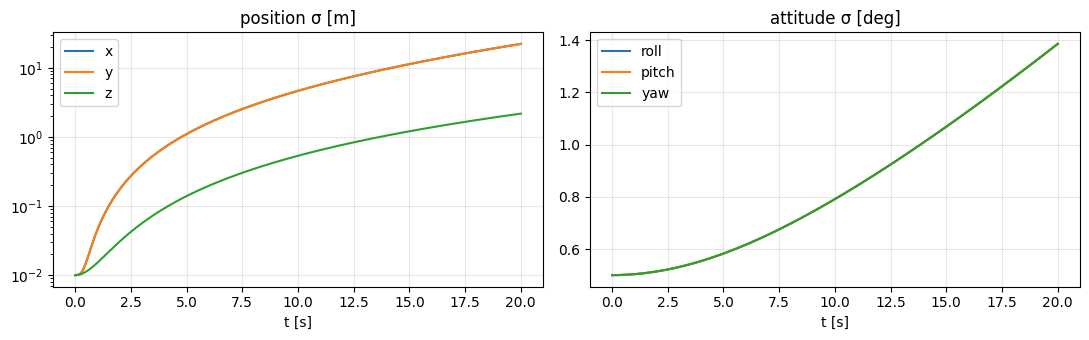

In [20]:
P = np.diag(np.r_[np.full(3, 0.01**2), np.full(3, 0.01**2), np.full(3, np.deg2rad(0.5)**2),
                  np.full(3, 0.01**2), np.full(3, 0.001**2)])
x = x_rest
sig_p, sig_th, times = [], [], []
for k in range(4000):                                     # 20 s
    x, P = predict(x, P, np.array([0, 0, 9.81]), np.zeros(3), dt, params)
    times.append((k + 1) * dt)
    sig_p.append(np.sqrt(np.diag(P)[P_IDX]))
    sig_th.append(np.degrees(np.sqrt(np.diag(P)[TH_IDX])))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].semilogy(times, sig_p); ax[0].set_title("position σ [m]"); ax[0].legend(["x", "y", "z"])
ax[1].plot(times, sig_th); ax[1].set_title("attitude σ [deg]"); ax[1].legend(["roll", "pitch", "yaw"])
for a in ax: a.set_xlabel("t [s]")
plt.tight_layout()

Horizontal position ($x$ and $y$, the two lines overlap) becomes uncertain much faster than vertical position ($z$). The reason is the $-\mathbf R[\mathbf a]_\times$ block of $\mathbf F_x$: an unknown roll or pitch error tilts the $9.81$ m/s² gravity vector into the horizontal plane, and that error is integrated twice. Vertical position only suffers from accelerometer noise and bias.

Attitude uncertainty grows at the same rate about all three axes, driven by the uncertain gyroscope bias. For a body at rest, roll and pitch errors feed into position, but a yaw error does not, because rotating about the gravity vector does not change the gravity projection.

### 4.4 Checking $\mathbf F_x$ numerically

Derivations are easy to get wrong, so we verify them. We perturb the error state by a tiny $\delta\mathbf x$ in each direction, propagate both the nominal state and the perturbed ("true") state with the *non-linear* model, and measure how the error changed. The ratio is a column of $\mathbf F_x$.

In [21]:
x_test = dict(p=np.zeros(3), v=np.array([1.0, 0.5, 0.0]), q=q_exp([0.3, -0.2, 0.5]),
              ab=np.array([0.05, 0.02, -0.03]), wb=np.array([0.01, 0.0, 0.02]))
a_m, w_m, dt_test = np.array([0.3, -0.2, 9.9]), np.array([0.2, -0.1, 0.3]), 0.01

x_next = nominal_predict(x_test, a_m, w_m, dt_test, params)
F_numeric, eps = np.zeros((15, 15)), 1e-6
for i in range(15):
    d = np.zeros(15)
    d[i] = eps                                                         # perturb one error direction
    x_true_next = nominal_predict(state_plus(x_test, d), a_m, w_m, dt_test, params)
    F_numeric[:, i] = state_minus(x_true_next, x_next) / eps          # how did the error change?

F_analytic = error_state_jacobian(x_test, a_m, w_m, dt_test)
diff = np.abs(F_analytic - F_numeric)

In [22]:
names = ["δp", "δv", "δθ", "δa_b", "δω_b"]
print(f"largest |F_analytic - F_numeric| per 3x3 block   (dt = {dt_test})")
print("        " + "".join(f"{n:>10}" for n in names))
for r in range(5):
    print(f"{names[r]:>6}  " + "".join(f"{diff[3*r:3*r+3, 3*c:3*c+3].max():10.1e}" for c in range(5)))

largest |F_analytic - F_numeric| per 3x3 block   (dt = 0.01)
                δp        δv        δθ      δa_b      δω_b
    δp     7.3e-13   5.9e-14   4.3e-04   4.7e-05   0.0e+00
    δv     0.0e+00   8.2e-11   4.7e-08   3.8e-11   0.0e+00
    δθ     0.0e+00   0.0e+00   6.0e-11   0.0e+00   1.4e-05
  δa_b     0.0e+00   0.0e+00   0.0e+00   1.0e-12   0.0e+00
  δω_b     0.0e+00   0.0e+00   0.0e+00   0.0e+00   1.0e-12


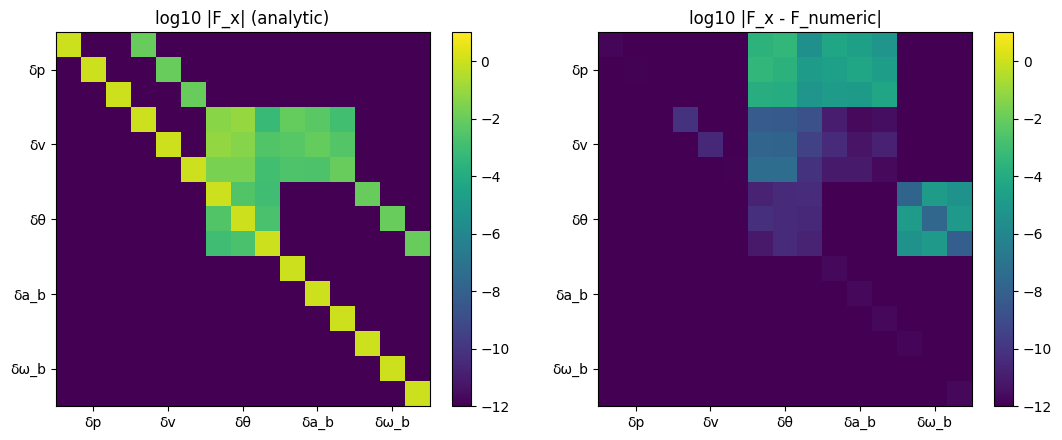

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, M, title in [(ax[0], np.log10(np.abs(F_analytic) + 1e-12), "log10 |F_x| (analytic)"),
                    (ax[1], np.log10(diff + 1e-12), "log10 |F_x - F_numeric|")]:
    im = a.imshow(M, cmap="viridis", vmin=-12, vmax=1)
    a.set_xticks(np.arange(1, 15, 3), names); a.set_yticks(np.arange(1, 15, 3), names)
    a.set_title(title); a.grid(False); plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout()

Almost every block agrees to numerical precision. Three blocks show a small but real mismatch:

* $\delta\mathbf p$ w.r.t. $\delta\boldsymbol\theta$ and $\delta\mathbf a_b$. The nominal position update contains $\tfrac12\mathbf R(\mathbf a_m-\mathbf a_b)\Delta t^2$, and the analytic $\mathbf F_x$ drops its sensitivity to attitude and bias. The missing terms are $-\tfrac12\mathbf R[\mathbf a]_\times\Delta t^2$ and $-\tfrac12\mathbf R\Delta t^2$.
* $\delta\boldsymbol\theta$ w.r.t. $\delta\boldsymbol\omega_b$. The exact block is $-\mathbf J_r\big((\boldsymbol\omega_m-\boldsymbol\omega_b)\Delta t\big)\Delta t$, with $\mathbf J_r$ the right Jacobian of SO(3). Solà approximates $\mathbf J_r\approx\mathbf I$, which is off by $O(\|\boldsymbol\omega\|\Delta t^2)$.

All three are second order in $\Delta t$ and are dropped on purpose. You can confirm this by rerunning the check with `dt_test = 0.001`: these entries shrink by a factor of 100, while a genuine derivation error would only shrink by 10 or not at all. The tiny values elsewhere are finite-difference noise. Exercise 1 asks you to add the missing terms.

## 5. Correction: update, inject, reset

### 5.1 Update

A measurement $\mathbf y = h(\mathbf x_t) + \mathbf v$, $\mathbf v\sim\mathcal N(0,\mathbf V)$, is used in the usual Kalman way, but the Jacobian is taken **with respect to the error state** (Solà eqs. 274-278):

$$
\mathbf K = \mathbf P\mathbf H^\top(\mathbf H\mathbf P\mathbf H^\top + \mathbf V)^{-1},
\qquad
\delta\hat{\mathbf x} = \mathbf K\,\mathbf r,
\qquad
\mathbf P \leftarrow (\mathbf I-\mathbf K\mathbf H)\mathbf P(\mathbf I-\mathbf K\mathbf H)^\top + \mathbf K\mathbf V\mathbf K^\top .
$$


This is the standard Kalman update. It works for any measurement once we know its residual $\mathbf r$, Jacobian $\mathbf H$ and noise $\mathbf V$. It also returns the normalised innovation squared (NIS), which we use in Section 8.

In [24]:
def kalman_update(P, r, H, V):
    S = H @ P @ H.T + V                       # innovation covariance
    K = P @ H.T @ np.linalg.inv(S)            # Kalman gain
    dx = K @ r                                # estimated error state
    I_KH = np.eye(15) - K @ H
    P = I_KH @ P @ I_KH.T + K @ V @ K.T       # Joseph form: keeps P symmetric and positive definite
    nis = r @ np.linalg.solve(S, r)
    return dx, P, nis

### 5.2 Inject

The estimated error is folded into the nominal state (Solà eq. 282):

$$
\mathbf p \leftarrow \mathbf p + \delta\hat{\mathbf p},\quad
\mathbf v \leftarrow \mathbf v + \delta\hat{\mathbf v},\quad
\mathbf q \leftarrow \mathbf q \otimes \mathrm{Exp}(\delta\hat{\boldsymbol\theta}),\quad
\mathbf a_b \leftarrow \mathbf a_b + \delta\hat{\mathbf a}_b,\quad
\boldsymbol\omega_b \leftarrow \boldsymbol\omega_b + \delta\hat{\boldsymbol\omega}_b
$$


This is exactly $\mathbf x \oplus \delta\hat{\mathbf x}$, and we already wrote it in Section 3: `state_plus(x, dx)`. Nothing new to code.

### 5.3 Reset

After injection the error mean is zero again. The orientation error is, however, now defined relative to a *new* nominal quaternion, so the covariance is re-expressed around it (Solà eqs. 285-287):

$$
\mathbf P \leftarrow \mathbf G\,\mathbf P\,\mathbf G^\top,
\qquad
\mathbf G = \mathrm{diag}\big(\mathbf I,\ \mathbf I,\ \mathbf I - [\tfrac12\delta\hat{\boldsymbol\theta}]_\times,\ \mathbf I,\ \mathbf I\big).
$$

In practice $\mathbf G\approx\mathbf I$ and many implementations skip it. We keep it for correctness.

In [25]:
def reset_covariance(P, dx):
    G = np.eye(15)
    G[TH_IDX, TH_IDX] = np.eye(3) - skew(0.5 * dx[TH_IDX])
    return G @ P @ G.T

### 5.4 One correction = update, inject, reset

In [26]:
def correct(x, P, r, H, V):
    dx, P, nis = kalman_update(P, r, H, V)    # 5.1
    x = state_plus(x, dx)                     # 5.2 inject
    P = reset_covariance(P, dx)               # 5.3 reset
    return x, P, nis

### 5.5 The pose measurement

For a **6D pose** measurement $(\mathbf p_m, \mathbf q_m)$, the kind a pose estimator, a motion-capture system or a visual marker would give you, we write the residual directly in the tangent space:

$$
\mathbf r = \begin{bmatrix}\mathbf p_m - \mathbf p\\ \mathbf q_m \boxminus \mathbf q\end{bmatrix},
\qquad
\mathbf H = \begin{bmatrix}\mathbf I & 0 & 0 & 0 & 0\\ 0 & 0 & \mathbf I & 0 & 0\end{bmatrix}.
$$

Because the orientation residual is already a local rotation vector, its Jacobian w.r.t. $\delta\boldsymbol\theta$ is simply $\mathbf I$ (to first order). No $4\times3$ quaternion Jacobian is needed. This is one of the practical conveniences of the error-state formulation.


We also add a position-only measurement, used in the exercises.

In [27]:
def update_pose(x, P, p_meas, q_meas, sigma_p, sigma_theta):
    r = np.r_[p_meas - x["p"],                    # position residual
              q_boxminus(q_meas, x["q"])]         # orientation residual, a 3-vector
    H = np.zeros((6, 15))
    H[0:3, P_IDX] = np.eye(3)
    H[3:6, TH_IDX] = np.eye(3)
    V = np.diag(np.r_[np.full(3, sigma_p**2), np.full(3, sigma_theta**2)])
    return correct(x, P, r, H, V)


def update_position(x, P, p_meas, sigma_p):
    r = p_meas - x["p"]
    H = np.zeros((3, 15))
    H[:, P_IDX] = np.eye(3)
    V = np.eye(3) * sigma_p**2
    return correct(x, P, r, H, V)

**Test.** Take the uncertain state from the prediction test above (20 s without measurements) and apply a single pose measurement. What should happen?

* Position drops straight to the sensor noise level ($5$ cm), because it is measured directly and was very uncertain.
* Attitude improves, but only partly, because the prior ($1.4°$) and the measurement ($2°$) are of similar quality.
* Velocity is not measured at all, yet it improves, because the prediction made it correlated with position and attitude.

In [28]:
def sigmas(P):
    s = np.sqrt(np.diag(P))
    return f"σ_p = {s[P_IDX]} m   σ_v = {s[V_IDX]} m/s   σ_θ = {np.degrees(s[TH_IDX])} deg"

print("before:", sigmas(P))
x, P, nis = update_pose(x, P, p_meas=x["p"], q_meas=x["q"], sigma_p=0.05, sigma_theta=np.deg2rad(2))
print("after: ", sigmas(P))

before: σ_p = [22.1353 22.1353  2.1704] m   σ_v = [2.7345 2.7345 0.2259] m/s   σ_θ = [1.3861 1.3861 1.3861] deg
after:  σ_p = [0.05 0.05 0.05] m   σ_v = [0.5584 0.5584 0.0352] m/s   σ_θ = [0.6893 0.6893 1.1393] deg


Notice also that roll and pitch improve *more* than yaw. They are correlated with horizontal position (through the tilted gravity), so the position measurement tells the filter something about them. Yaw has no such link here. This is the Kalman filter using correlations, not just the measured states.

That is the complete filter: `predict` for every IMU sample, `update_pose` for every pose measurement. The rest of the notebook tests it on data.

## 6. The dataset

The simulator generates a slowly manoeuvring vehicle, for example an ROV. Truth is produced with the same discretisation as the filter, so any inconsistency we find later comes from the filter and not from the simulator.

| sensor | rate | noise |
|---|---|---|
| IMU (accelerometer + gyroscope) | 200 Hz | $\sigma_{a_n}=0.05$ m/s², $\sigma_{\omega_n}=0.005$ rad/s, biases with random walk |
| 6D pose | 10 Hz | $\sigma_p = 5$ cm, $\sigma_\theta = 2°$ |

Between $t = 30$ s and $t = 40$ s there are **no pose measurements**, which mimics an occlusion or a detector failure. During that window the filter can only integrate the IMU.

The data is also written to `data/` as plain CSV, so you can swap in your own logs with the same columns and skip the simulation:

* `imu.csv`: `t, ax, ay, az, wx, wy, wz` (body frame, m/s² and rad/s)
* `pose_measurements.csv`: `t, px, py, pz, qw, qx, qy, qz`
* `ground_truth.csv` (optional): `t, px..pz, vx..vz, qw..qz, abx..abz, wbx..wbz`

In [29]:
@dataclass
class SimConfig:
    duration: float = 60.0
    imu_rate: float = 200.0
    pose_rate: float = 10.0
    dropout: tuple = (30.0, 40.0)            # seconds without pose measurements
    sigma_an: float = 0.05                   # IMU noise: same values as ESKFParams
    sigma_wn: float = 0.005
    sigma_aw: float = 0.002
    sigma_ww: float = 0.0002
    ab0: tuple = (0.08, -0.05, 0.10)         # true initial accelerometer bias [m/s²]
    wb0: tuple = (0.010, -0.008, 0.012)      # true initial gyroscope bias     [rad/s]
    sigma_p: float = 0.05                    # pose sensor noise [m]
    sigma_theta: float = np.deg2rad(2.0)     # pose sensor noise [rad]
    gravity: tuple = (0.0, 0.0, -9.81)
    seed: int = 0

The true motion is defined by a smooth world-frame acceleration and body-frame angular rate. Everything else follows by integration.

In [30]:
def true_motion(t):
    acc_world = np.array([0.3 * np.cos(0.3 * t), 0.3 * np.sin(0.2 * t), 0.05 * np.sin(0.1 * t)])
    w_body = np.array([0.20 * np.sin(0.4 * t), 0.15 * np.sin(0.3 * t + 1.0), 0.25 * np.cos(0.15 * t)])
    return acc_world, w_body

The two sensors. The IMU follows the measurement model of Section 3. The pose sensor returns the true pose with noise, the orientation noise applied with $\boxplus$.

In [31]:
def imu_sample(t, x_true, cfg, rng):
    acc_world, w_body = true_motion(t)
    g = np.array(cfg.gravity)
    a_m = q_to_R(x_true["q"]).T @ (acc_world - g) + x_true["ab"] + cfg.sigma_an * rng.standard_normal(3)
    w_m = w_body + x_true["wb"] + cfg.sigma_wn * rng.standard_normal(3)
    return a_m, w_m


def pose_sample(x_true, cfg, rng):
    p_m = x_true["p"] + cfg.sigma_p * rng.standard_normal(3)
    q_m = q_boxplus(x_true["q"], cfg.sigma_theta * rng.standard_normal(3))
    return p_m, q_m

The true state is propagated with the same discretisation as the filter, and the biases perform a random walk.

In [32]:
def propagate_truth(x, t, dt, cfg, rng):
    acc_world, w_body = true_motion(t)
    return dict(p=x["p"] + x["v"] * dt + 0.5 * acc_world * dt**2,
                v=x["v"] + acc_world * dt,
                q=q_boxplus(x["q"], w_body * dt),
                ab=x["ab"] + cfg.sigma_aw * np.sqrt(dt) * rng.standard_normal(3),
                wb=x["wb"] + cfg.sigma_ww * np.sqrt(dt) * rng.standard_normal(3))

The simulation loop records the truth at every step, a pose measurement every 20th step (except in the dropout), and an IMU sample.

In [33]:
def simulate(cfg=SimConfig()):
    rng = np.random.default_rng(cfg.seed)
    dt = 1.0 / cfg.imu_rate
    n_steps = int(round(cfg.duration * cfg.imu_rate))
    pose_every = int(round(cfg.imu_rate / cfg.pose_rate))

    x = dict(p=np.zeros(3), v=np.array([0.0, -1.5, -0.5]), q=np.array([1.0, 0, 0, 0]),
             ab=np.array(cfg.ab0), wb=np.array(cfg.wb0))
    truth, imu, pose = [], [], []
    for k in range(n_steps + 1):
        t = k * dt
        truth.append([t, *x["p"], *x["v"], *x["q"], *x["ab"], *x["wb"]])

        in_dropout = cfg.dropout[0] <= t < cfg.dropout[1]
        if k % pose_every == 0 and not in_dropout:
            p_m, q_m = pose_sample(x, cfg, rng)
            pose.append([t, *p_m, *q_m])

        if k < n_steps:
            a_m, w_m = imu_sample(t, x, cfg, rng)
            imu.append([t, *a_m, *w_m])
            x = propagate_truth(x, t, dt, cfg, rng)
    return to_dataframes(truth, imu, pose)

Finally, small helpers to turn the lists into tables and to read and write them as CSV.

In [34]:
TRUTH_COLS = dict(p=["px", "py", "pz"], v=["vx", "vy", "vz"], q=["qw", "qx", "qy", "qz"],
                  ab=["abx", "aby", "abz"], wb=["wbx", "wby", "wbz"])


def to_dataframes(truth, imu, pose):
    truth = pd.DataFrame(truth, columns=["t"] + sum(TRUTH_COLS.values(), []))
    imu = pd.DataFrame(imu, columns=["t", "ax", "ay", "az", "wx", "wy", "wz"])
    pose = pd.DataFrame(pose, columns=["t", "px", "py", "pz", "qw", "qx", "qy", "qz"])
    return truth, imu, pose


def save_dataset(folder, truth, imu, pose):
    os.makedirs(folder, exist_ok=True)
    truth.to_csv(f"{folder}/ground_truth.csv", index=False, float_format="%.9f")
    imu.to_csv(f"{folder}/imu.csv", index=False, float_format="%.9f")
    pose.to_csv(f"{folder}/pose_measurements.csv", index=False, float_format="%.9f")


def load_dataset(folder):
    truth = pd.read_csv(f"{folder}/ground_truth.csv")
    imu = pd.read_csv(f"{folder}/imu.csv")
    pose = pd.read_csv(f"{folder}/pose_measurements.csv")
    return truth, imu, pose

Generate the data, save it, and read it back the way real logs would be read:

In [35]:
cfg = SimConfig(seed=0)
truth, imu, pose = simulate(cfg)
save_dataset("data", truth, imu, pose)
truth, imu, pose = load_dataset("data")
print(f"{len(imu)} IMU samples, {len(pose)} pose measurements")
imu.head()

12000 IMU samples, 501 pose measurements


,t,ax,ay,az,wx,wy,wz
0,0.000,0.445200,-0.002646,9.874813,0.003673,0.115104,0.262207
1,0.005,0.394061,0.002024,9.903609,0.017222,0.115008,0.263753
2,0.010,0.316929,-0.060591,9.902178,0.013481,0.119522,0.263775
3,0.015,0.428407,-0.011102,9.923678,0.009628,0.125842,0.271821
4,0.020,0.290739,-0.030214,9.932200,0.015061,0.112752,0.258720


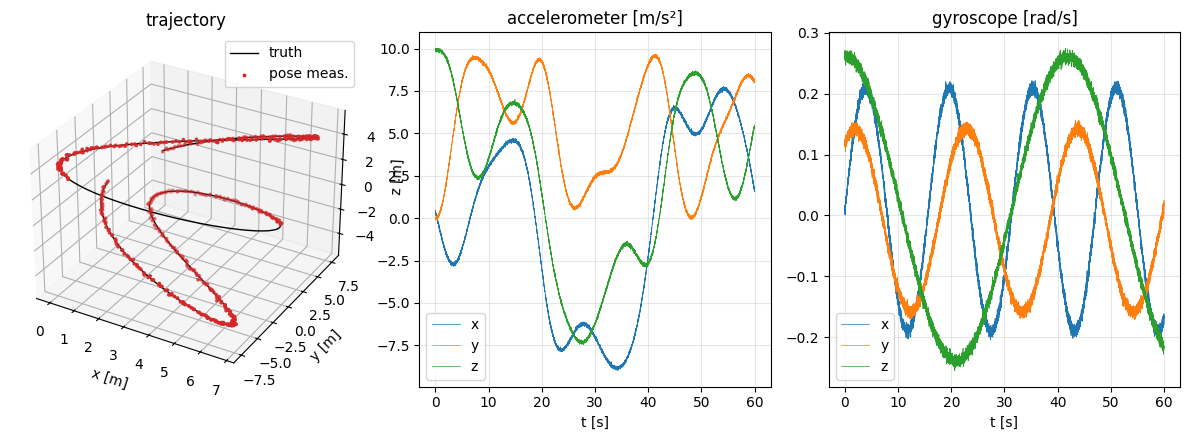

In [36]:
fig = plt.figure(figsize=(12, 4.5))
ax3 = fig.add_subplot(1, 3, 1, projection="3d")
ax3.plot(truth.px, truth.py, truth.pz, "k", lw=1, label="truth")
ax3.scatter(pose.px, pose.py, pose.pz, s=3, c="tab:red", label="pose meas.")
ax3.set_xlabel("x [m]"); ax3.set_ylabel("y [m]"); ax3.set_zlabel("z [m]"); ax3.legend()
ax3.set_title("trajectory")

ax = fig.add_subplot(1, 3, 2)
ax.plot(imu.t, imu[["ax", "ay", "az"]].to_numpy(), lw=0.5)
ax.set_title("accelerometer [m/s²]"); ax.set_xlabel("t [s]"); ax.legend(["x", "y", "z"])
ax = fig.add_subplot(1, 3, 3)
ax.plot(imu.t, imu[["wx", "wy", "wz"]].to_numpy(), lw=0.5)
ax.set_title("gyroscope [rad/s]"); ax.set_xlabel("t [s]"); ax.legend(["x", "y", "z"])
plt.tight_layout()

Look at the scale of the accelerometer signal. The vehicle's own acceleration is at most $0.3$ m/s², yet the readings swing between about $-9$ and $+10$ m/s². An accelerometer measures specific force, so almost everything you see is gravity, redistributed across the axes as the vehicle rolls and pitches (at $t=0$ the body is level and $z$ reads $+9.8$). To recover the tiny motion signal, the filter must subtract gravity using its attitude estimate. This is why a small attitude error is so harmful. A $1°$ tilt error leaves $9.81\sin 1° \approx 0.17$ m/s² of gravity in the wrong axis, which becomes about $8.5$ m of position error after only $10$ s.

In the 3D plot, the stretch of black line without red dots is the dropout window.

## 7. Running the filter

The whole filter is the loop below. For every IMU sample it does three things: apply any pose measurements that have arrived, store the current estimate, and predict to the next IMU time.

In [37]:
def run_eskf(imu, pose, x0, P0, params, sigma_p, sigma_theta, use_pose=True):
    t_imu, acc, gyro = imu["t"].to_numpy(), imu[["ax", "ay", "az"]].to_numpy(), imu[["wx", "wy", "wz"]].to_numpy()
    t_pose, p_meas, q_meas = pose["t"].to_numpy(), pose[["px", "py", "pz"]].to_numpy(), pose[["qw", "qx", "qy", "qz"]].to_numpy()

    x, P = x0, P0
    estimates, covariances, nis_values = [], [], []
    j = 0                                                   # index of the next pose measurement
    for k in range(len(t_imu)):
        # 1) correct with every pose measurement that has arrived by time t_k
        while use_pose and j < len(t_pose) and t_pose[j] <= t_imu[k]:
            x, P, nis = update_pose(x, P, p_meas[j], q_meas[j], sigma_p, sigma_theta)
            nis_values.append(nis)
            j += 1
        # 2) store the estimate at time t_k
        estimates.append(x)
        covariances.append(P)
        # 3) predict to the next IMU time
        dt = t_imu[k + 1] - t_imu[k] if k + 1 < len(t_imu) else t_imu[k] - t_imu[k - 1]
        x, P = predict(x, P, acc[k], gyro[k], dt, params)
    return estimates, np.array(covariances), np.array(nis_values)

We initialise from the first pose measurement, guess zero velocity and zero biases. The true velocity is about $1.6$ m/s, so we give velocity a large initial uncertainty.

In [38]:
params = ESKFParams(cfg.sigma_an, cfg.sigma_wn, cfg.sigma_aw, cfg.sigma_ww, cfg.gravity)

x0 = dict(p=pose.loc[0, ["px", "py", "pz"]].to_numpy(),
          v=np.zeros(3),
          q=pose.loc[0, ["qw", "qx", "qy", "qz"]].to_numpy(),
          ab=np.zeros(3),
          wb=np.zeros(3))

P0 = np.diag(np.r_[np.full(3, 0.1**2),               # position   [m²]
                   np.full(3, 2.0**2),               # velocity   [(m/s)²]
                   np.full(3, np.deg2rad(5)**2),     # attitude   [rad²]
                   np.full(3, 0.2**2),               # accel bias [(m/s²)²]
                   np.full(3, 0.02**2)])             # gyro bias  [(rad/s)²]

In [39]:
estimates, covariances, nis_values = run_eskf(imu, pose, x0, P0, params, cfg.sigma_p, cfg.sigma_theta)
print(f"{len(estimates)} estimates, {len(nis_values)} pose updates")

12000 estimates, 500 pose updates


### 7.1 Comparing with the truth

To compare, we need the true state at each time step, and the error between truth and estimate. The error is computed with `state_minus`, so it lives in the same 15-dim space as $\mathbf P$, and we can draw $\pm3\sigma$ bounds from the diagonal of $\mathbf P$.

In [40]:
def truth_state(truth, k):
    """The true state at row k of the ground-truth table, as a state dictionary."""
    return {key: truth.loc[k, cols].to_numpy(dtype=float) for key, cols in TRUTH_COLS.items()}


t = imu["t"].to_numpy()
errors = np.array([state_minus(truth_state(truth, k), estimates[k]) for k in range(len(t))])
sigma = np.sqrt(np.diagonal(covariances, axis1=1, axis2=2))

has_meas = (t > 5) & ((t < cfg.dropout[0]) | (t > cfg.dropout[1] + 2))
print(f"position RMSE (whole run)       : {np.sqrt(np.mean(np.sum(errors[:, P_IDX]**2, 1))) * 100:.1f} cm")
print(f"position RMSE (with measurements): {np.sqrt(np.mean(np.sum(errors[has_meas, P_IDX]**2, 1))) * 100:.1f} cm")
print(f"attitude RMSE (with measurements): {np.degrees(np.sqrt(np.mean(np.sum(errors[has_meas, TH_IDX]**2, 1)))):.2f} deg")

position RMSE (whole run)       : 14.3 cm
position RMSE (with measurements): 3.3 cm
attitude RMSE (with measurements): 0.32 deg


In [41]:
def plot_error(block, title, unit, scale=1.0, ylim=None):
    """Error (blue) and ±3σ band (orange) for one 3-vector block of the error state."""
    fig, axs = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
    for i, (ax, c) in enumerate(zip(axs, "xyz")):
        col = block.start + i
        ax.plot(t, scale * errors[:, col], lw=0.8, label="error")
        ax.fill_between(t, -3 * scale * sigma[:, col], 3 * scale * sigma[:, col], color="C1", alpha=0.25, label="±3σ")
        ax.axvspan(*cfg.dropout, color="grey", alpha=0.15, lw=0)
        ax.set_title(f"{title} {c}"); ax.set_xlabel("t [s]")
        if ylim: ax.set_ylim(ylim)
    axs[0].set_ylabel(unit); axs[0].legend(loc="upper left")
    plt.tight_layout()

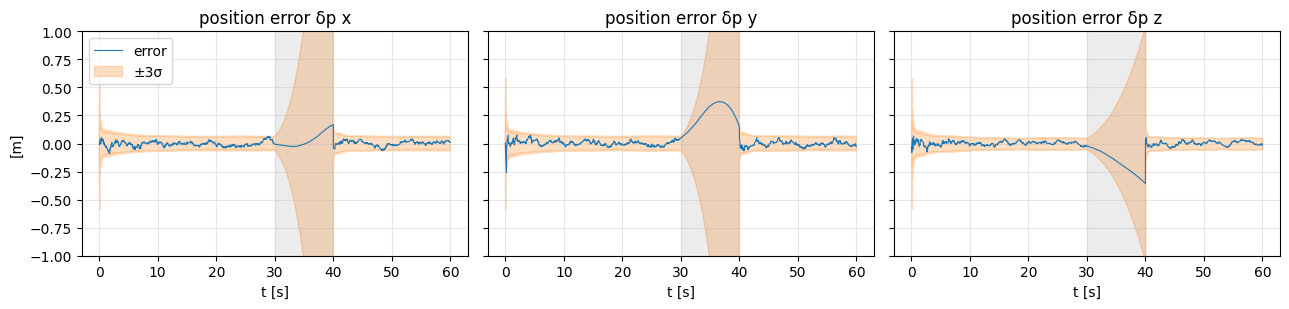

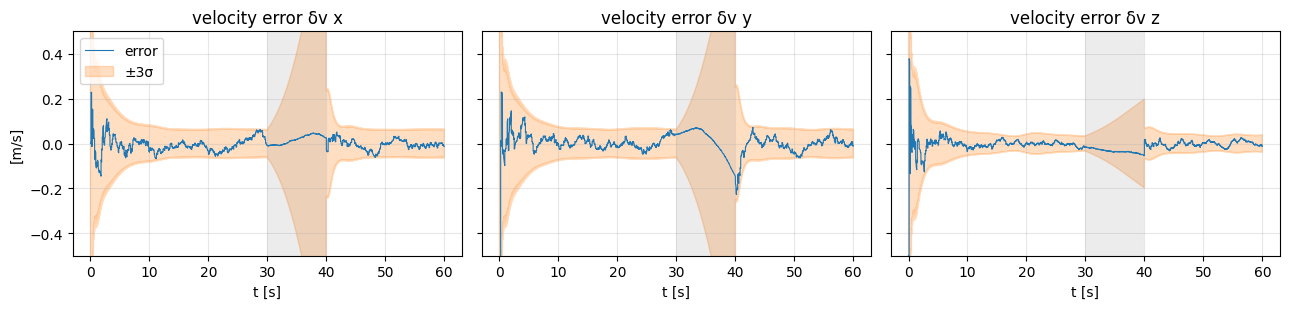

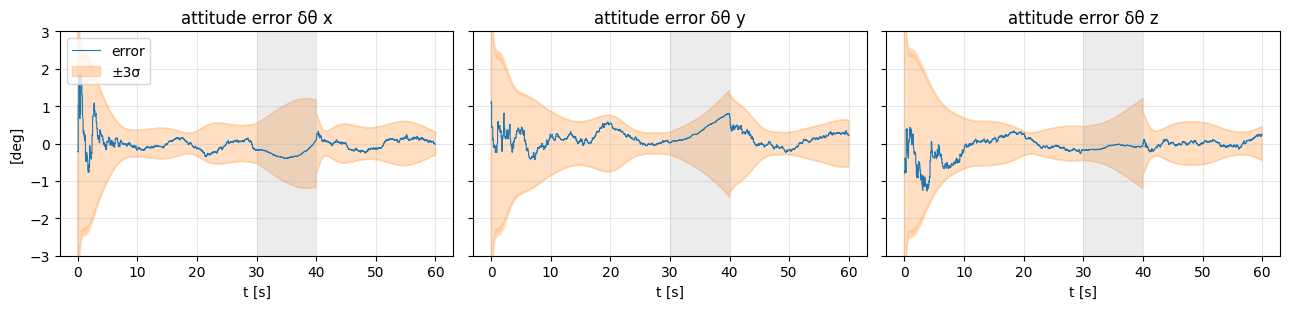

In [42]:
plot_error(P_IDX, "position error δp", "[m]", ylim=(-1.0, 1.0))
plot_error(V_IDX, "velocity error δv", "[m/s]", ylim=(-0.5, 0.5))
plot_error(TH_IDX, "attitude error δθ", "[deg]", scale=np.degrees(1), ylim=(-3, 3))

Things to notice:

* The error (blue) stays inside the $\pm3\sigma$ envelope (orange). The filter's uncertainty is a truthful description of its actual error. Section 8 tests this properly.
* Velocity was initialised $1.6$ m/s wrong and converges within a second, although velocity is never measured. It is observed through the change of position over time.
* In the grey dropout window the $\pm3\sigma$ envelope opens quickly, fastest in horizontal position, where tilt errors map gravity into $x$ and $y$ (as seen in the prediction test of Section 4.3). The actual error also grows, but stays inside the envelope.
* When measurements return at $t = 40$ s, the filter snaps back in one update.

### 7.2 Bias estimates

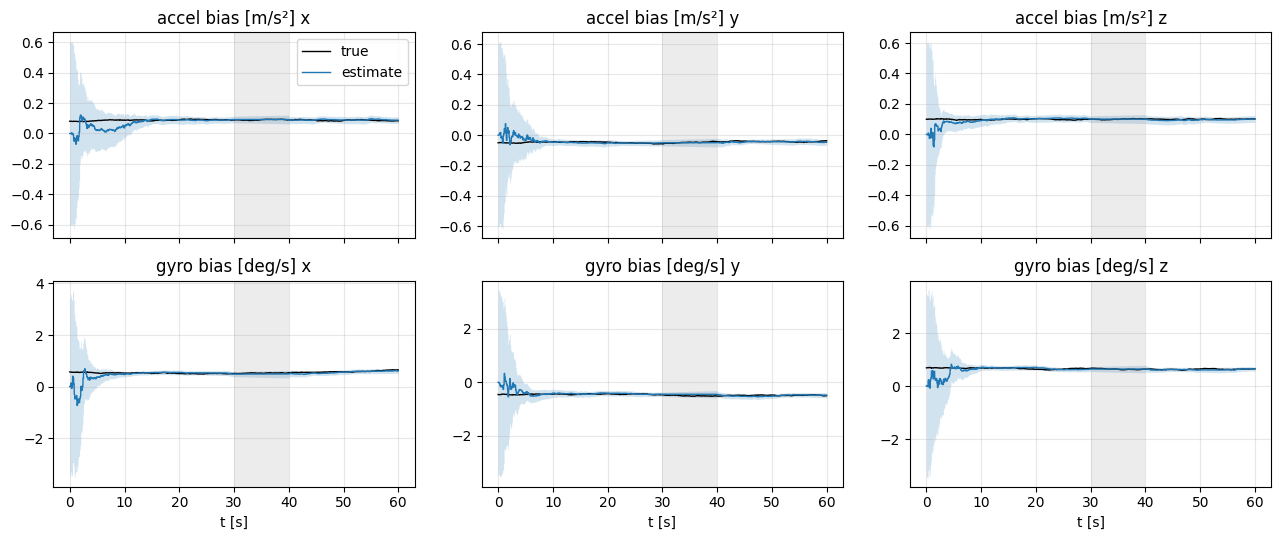

In [43]:
est_ab = np.array([x["ab"] for x in estimates])
est_wb = np.array([x["wb"] for x in estimates])
true_ab = truth[TRUTH_COLS["ab"]].to_numpy()[:len(t)]
true_wb = truth[TRUTH_COLS["wb"]].to_numpy()[:len(t)]

fig, axs = plt.subplots(2, 3, figsize=(13, 5.5), sharex=True)
for i, c in enumerate("xyz"):
    for row, (est, true, block, name, scale) in enumerate([(est_ab, true_ab, AB_IDX, "accel bias [m/s²]", 1.0),
                                                           (est_wb, true_wb, WB_IDX, "gyro bias [deg/s]", np.degrees(1))]):
        ax = axs[row, i]
        s = 3 * sigma[:, block.start + i]
        ax.plot(t, scale * true[:, i], "k", lw=1, label="true")
        ax.plot(t, scale * est[:, i], "C0", lw=1, label="estimate")
        ax.fill_between(t, scale * (est[:, i] - s), scale * (est[:, i] + s), color="C0", alpha=0.2, lw=0)
        ax.axvspan(*cfg.dropout, color="grey", alpha=0.15, lw=0)
        ax.set_title(f"{name} {c}")
axs[0, 0].legend()
for ax in axs[1]: ax.set_xlabel("t [s]")
plt.tight_layout()

The biases start at zero and are pulled towards the truth. Gyro biases converge quickly because orientation is measured directly. Accelerometer biases take longer: the filter must separate "the accelerometer is biased" from "the vehicle is tilted" (both change the gravity projection), and that separation only becomes possible once the vehicle has rotated enough. This is an **observability** question. Try Exercise 3 to see what happens with a vehicle that never rotates.

### 7.3 Why bother? Pure IMU dead reckoning

Now run the same code but *never* apply a pose update (`use_pose=False`). This is pure strapdown integration, starting from the perfect initial state but with unknown biases.

In [44]:
x0_perfect = truth_state(truth, 0)
x0_perfect["ab"], x0_perfect["wb"] = np.zeros(3), np.zeros(3)      # the biases are unknown

dr_estimates, _, _ = run_eskf(imu, pose, x0_perfect, P0 * 1e-6, params, cfg.sigma_p, cfg.sigma_theta, use_pose=False)

p_true = truth[TRUTH_COLS["p"]].to_numpy()[:len(t)]
p_eskf = np.array([x["p"] for x in estimates])
p_dr = np.array([x["p"] for x in dr_estimates])
print(f"IMU-only position error after {t[-1]:.0f} s: {np.linalg.norm(p_true[-1] - p_dr[-1]):.0f} m")

IMU-only position error after 60 s: 3721 m


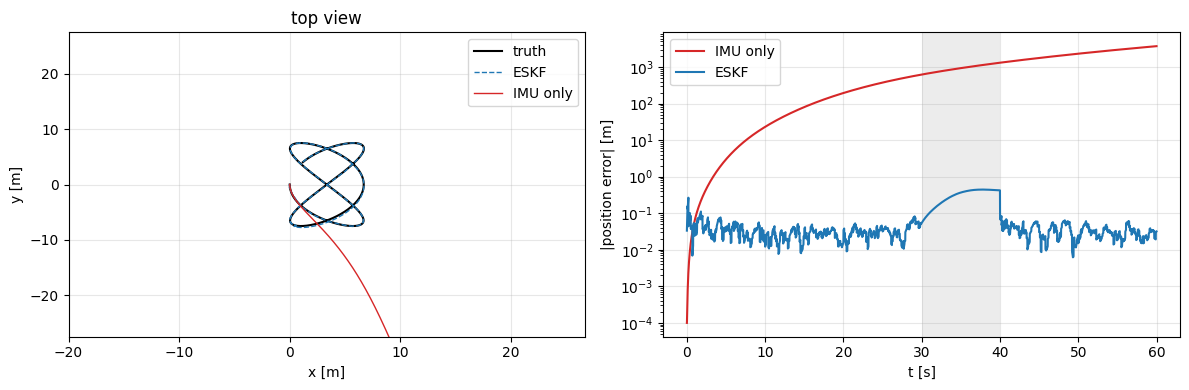

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(p_true[:, 0], p_true[:, 1], "k", lw=1.5, label="truth")
axs[0].plot(p_eskf[:, 0], p_eskf[:, 1], "C0--", lw=1, label="ESKF")
axs[0].plot(p_dr[:, 0], p_dr[:, 1], "C3", lw=1, label="IMU only")
axs[0].set_xlim(p_true[:, 0].min() - 20, p_true[:, 0].max() + 20)
axs[0].set_ylim(p_true[:, 1].min() - 20, p_true[:, 1].max() + 20)
axs[0].set_xlabel("x [m]"); axs[0].set_ylabel("y [m]"); axs[0].set_title("top view"); axs[0].legend()

axs[1].semilogy(t, np.linalg.norm(p_true - p_dr, axis=1) + 1e-4, "C3", label="IMU only")
axs[1].semilogy(t, np.linalg.norm(p_true - p_eskf, axis=1) + 1e-4, "C0", label="ESKF")
axs[1].axvspan(*cfg.dropout, color="grey", alpha=0.15, lw=0)
axs[1].set_xlabel("t [s]"); axs[1].set_ylabel("|position error| [m]"); axs[1].legend()
plt.tight_layout()

Uncorrected biases are integrated twice, so position error grows roughly with $t^2$ (and faster once attitude drifts). The IMU is excellent over short horizons and useless over long ones. The pose sensor is the opposite: noisy but drift-free. The ESKF takes the best of both.

## 8. Is the filter honest? Consistency tests

A filter can have a small error and still be wrong about *how* uncertain it is, which is dangerous when its covariance is used downstream (gating, fusion, planning). Two standard tests (Bar-Shalom et al., *Estimation with Applications to Tracking and Navigation*, Sec. 5.4):

**NEES** (normalised estimation error squared) needs ground truth:
$$\epsilon_k = \delta\mathbf x_k^\top\,\mathbf P_k^{-1}\,\delta\mathbf x_k \;\sim\; \chi^2_{15} \quad\text{if the filter is consistent.}$$

Averaged over $N$ Monte Carlo runs, $N\bar\epsilon_k \sim \chi^2_{15N}$, which gives a 95% acceptance band.

**NIS** (normalised innovation squared) needs *no* ground truth, so it also works on real data:
$$\nu_k = \mathbf r_k^\top\,\mathbf S_k^{-1}\,\mathbf r_k \;\sim\; \chi^2_{6}.$$


For NEES we repeat the whole experiment $N$ times with different random seeds. Each run starts from a random initial error drawn from $\mathbf P_0$, because the initial error must match the initial covariance for the test to be fair. Since truth $=\mathbf x_0\oplus\mathbf d$, the initial estimate is $\mathbf x_0 = $ truth $\oplus(-\mathbf d)$.

The function below does one run and returns its NEES values (every 10th step) and its NIS values.

In [46]:
def one_monte_carlo_run(seed, P0, stride=10):
    cfg_mc = SimConfig(seed=seed)
    truth_mc, imu_mc, pose_mc = simulate(cfg_mc)

    d = np.linalg.cholesky(P0) @ np.random.default_rng(seed + 1000).standard_normal(15)
    x0_mc = state_plus(truth_state(truth_mc, 0), -d)       # a random initial error drawn from P0

    est, cov, nis = run_eskf(imu_mc, pose_mc, x0_mc, P0, params, cfg_mc.sigma_p, cfg_mc.sigma_theta)

    nees = []
    for k in range(0, len(est), stride):
        e = state_minus(truth_state(truth_mc, k), est[k])
        nees.append(e @ np.linalg.solve(cov[k], e))
    return np.array(nees), nis

Now run it $N = 10$ times (about 30 seconds) and average the NEES over the runs.

In [47]:
N = 10
P0_mc = np.diag(np.r_[np.full(3, 0.1**2), np.full(3, 0.1**2), np.full(3, np.deg2rad(5)**2),
                      np.full(3, 0.15**2), np.full(3, 0.02**2)])

nees_runs, nis_runs = [], []
for s in range(N):
    nees, nis = one_monte_carlo_run(100 + s, P0_mc)
    nees_runs.append(nees)
    nis_runs.append(nis)

average_nees = np.mean(nees_runs, axis=0)
all_nis = np.concatenate(nis_runs)
lo, hi = chi2.ppf([0.025, 0.975], 15 * N) / N            # 95% band for the average of N runs
print(f"mean NEES = {average_nees.mean():.2f}  (ideal 15), fraction inside 95% band = {np.mean((average_nees > lo) & (average_nees < hi)):.0%}")
print(f"mean NIS  = {all_nis.mean():.2f}  (ideal 6)")

mean NEES = 16.13  (ideal 15), fraction inside 95% band = 85%
mean NIS  = 6.02  (ideal 6)


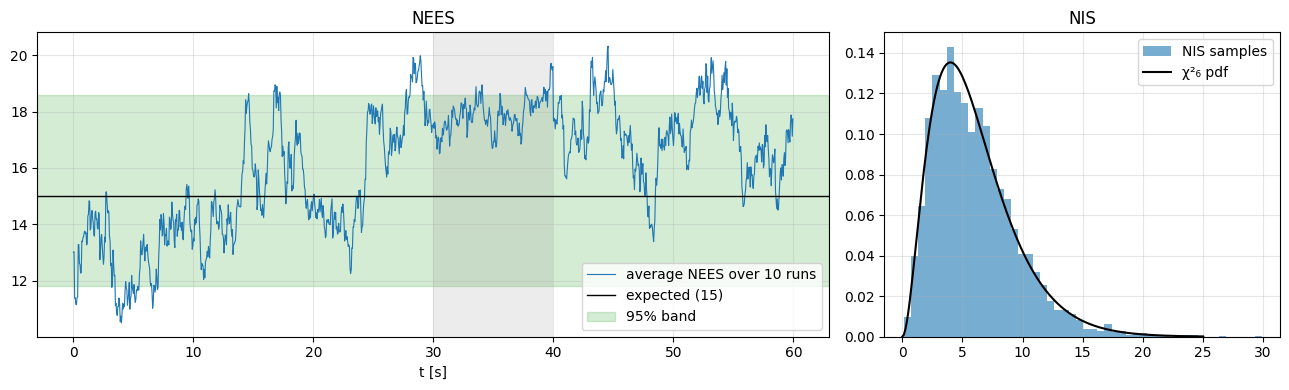

In [48]:
t_nees = t[::10]
fig, axs = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2, 1]})
axs[0].plot(t_nees, average_nees, lw=0.8, label=f"average NEES over {N} runs")
axs[0].axhline(15, color="k", lw=1, label="expected (15)")
axs[0].axhspan(lo, hi, color="C2", alpha=0.2, label="95% band")
axs[0].axvspan(*cfg.dropout, color="grey", alpha=0.15, lw=0)
axs[0].set_xlabel("t [s]"); axs[0].set_title("NEES"); axs[0].legend()

xs = np.linspace(0, 25, 200)
axs[1].hist(all_nis, bins=50, density=True, alpha=0.6, label="NIS samples")
axs[1].plot(xs, chi2.pdf(xs, 6), "k", label="χ²₆ pdf")
axs[1].set_title("NIS"); axs[1].legend()
plt.tight_layout()

The NIS histogram matches the $\chi^2_6$ density very well, and the average NEES stays in the neighbourhood of 15. Look closely, though: the NEES drifts slightly high in the second half and leaves the band now and then. The filter is consistent, but mildly over-confident. Likely contributors are the second-order terms dropped from $\mathbf F_x$ (Section 4.4) and the first-order approximations in the update and reset, and with only $N=10$ runs the average itself is still noisy. Increase `N` to separate the two effects. A NEES that sits far **above** the band means the filter is over-confident (its $\mathbf P$ is too small, typical when $\mathbf Q$ is under-tuned or the linearisation is poor). A NEES far **below** means it is too pessimistic and ignores information it could use.

On real data, NIS is the tool you have. Try Exercise 2 to see how mistuning shows up.

## 9. Exercises

1. **Second-order terms in $\mathbf F_x$.** Add $-\tfrac12\mathbf R[\mathbf a]_\times\Delta t^2$ and $-\tfrac12\mathbf R\Delta t^2$ to the $\delta\mathbf p$ row of `error_state_jacobian` (Section 4) and rerun the numerical check of Section 4.4. Does the NEES change noticeably at 200 Hz? What about at 20 Hz?
2. **Mistuning.** Run Section 8 with `ESKFParams(sigma_an=0.005, ...)` (10× too optimistic) and then with 10× too pessimistic noise. Watch NEES and NIS leave their bands.
3. **Observability.** Set the angular rate in `true_motion` (Section 6) to zero. Can the filter still separate accelerometer bias from tilt? Look at the bias plots and at the corresponding blocks of $\mathbf P$.
4. **Position-only updates.** In `run_eskf` (Section 7), replace `update_pose` with `update_position`. Which states lose accuracy? Why is yaw hit hardest?
5. **Global vs local error.** Solà Sec. 7 defines the orientation error in the world frame, $\mathbf q_t = \mathrm{Exp}(\delta\boldsymbol\theta)\otimes\mathbf q$. Rewrite $\mathbf F_x$, $\mathbf H$ and $\mathbf G$ for that convention and check that the results match.
6. **Estimate gravity.** Solà's full filter includes $\mathbf g$ in the state (18-dim error state). Add it and initialise it wrong by a few degrees.
7. **Your own data.** Replace the files in `data/` with a real IMU and pose log (same columns) and inspect the NIS. Remember to express the IMU in the body frame the pose refers to, and to handle the IMU-to-body extrinsic calibration.

## References

* J. Solà, *Quaternion kinematics for the error-state Kalman filter*, 2017. [arXiv:1711.02508](https://arxiv.org/abs/1711.02508)
* R. Labbe, *Kalman and Bayesian Filters in Python*, chapter 11: Extended Kalman Filters. [GitHub](https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python)
* Y. Bar-Shalom, X. R. Li, T. Kirubarajan, *Estimation with Applications to Tracking and Navigation*, Wiley, 2001.
* J. Solà, J. Deray, D. Atchuthan, *A micro Lie theory for state estimation in robotics*, 2018. [arXiv:1812.01537](https://arxiv.org/abs/1812.01537)